#### Modules

In [ ]:
import os
from pathlib import Path
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

#### Use GPU

In [3]:
# Select device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


#### Original CNN Architecture

In [4]:
class CNNBinary(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

#### Function for converting test images into tensors

In [5]:
def preprocess_image(image_path: Path) -> torch.Tensor:
    image = Image.open(image_path).convert("RGB")
    image_array = np.asarray(image, dtype=np.float32) / 255.0
    image_tensor = torch.from_numpy(np.transpose(image_array, (2, 0, 1))).unsqueeze(0)
    return image_tensor

#### Load Best wall and deck models

In [6]:
# Wall model
model_walls = CNNBinary().to(device)
model_walls.load_state_dict(torch.load(Path.cwd() / "model_walls_cleaned.pth", map_location=device))

# Deck model
model_decks = CNNBinary().to(device)
model_decks.load_state_dict(torch.load(Path.cwd() / "model_decks_cleaned.pth", map_location=device))

<All keys matched successfully>

#### Label Mystery test set
- `walls_label` comes from `model_walls_cleaned` with default threshold of 0.5.
- `decks_label` comes from `model_decks_cleaned` with default threshold of 0.5.
- `final_label` is the conservative ensemble label (cracked if either model predicts cracked).

In [7]:
# Path to direct to mystery test set
mystery_dir = Path.cwd() / "Mystery_Test_Set"
valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
image_paths = sorted([p for p in mystery_dir.rglob("*") if p.suffix.lower() in valid_exts])
if not image_paths:
    raise FileNotFoundError(f"No images found in {mystery_dir}")

# Labeling and ensemble logic
records = []
with torch.no_grad():
    for img_path in image_paths:
        x = preprocess_image(img_path).to(device)

        walls_prob = float(torch.sigmoid(model_walls(x)).item())
        decks_prob = float(torch.sigmoid(model_decks(x)).item())

        walls_label = "Cracked" if walls_prob >= 0.5 else "Non-Cracked"
        decks_label = "Cracked" if decks_prob >= 0.5 else "Non-Cracked"

        # Ensemble strategy: cracked if either specialized model flags a crack
        final_label = "Cracked" if (walls_label == "Cracked" or decks_label == "Cracked") else "Non-Cracked"
        ensemble_prob = max(walls_prob, decks_prob)

        records.append({"image_path": str(img_path.relative_to(Path.cwd())),
                        "walls_probability": walls_prob,
                        "decks_probability": decks_prob,
                        "walls_label": walls_label,
                        "decks_label": decks_label,
                        "ensemble_probability": ensemble_prob,
                        "final_label": final_label,})


In [12]:
# Results + save to CSV
results_df = pd.DataFrame(records).sort_values("image_path").reset_index(drop=True)
output_csv = Path.cwd() / "mystery_test_set_labels.csv"
results_df.to_csv(output_csv, index=False)

summary = pd.DataFrame({
    "Wall Model":  results_df["walls_label"].value_counts(),
    "Deck Model":  results_df["decks_label"].value_counts(),
    "Final (Ensemble)": results_df["final_label"].value_counts(),
}).fillna(0).astype(int)

print(f"Total images labeled: {len(results_df)}\n")
print(summary.to_string())


Total images labeled: 700

             Wall Model  Deck Model  Final (Ensemble)
Cracked             554         698               700
Non-Cracked         146           2                 0


#### Wall Model – First Conv Layer Filters
10 random images from the Mystery Test Set passed through the first convolutional block of `model_walls_cleaned`. Each row is one image; the first column is the original, the remaining 8 columns are the first 8 of the 32 feature maps produced by that block.

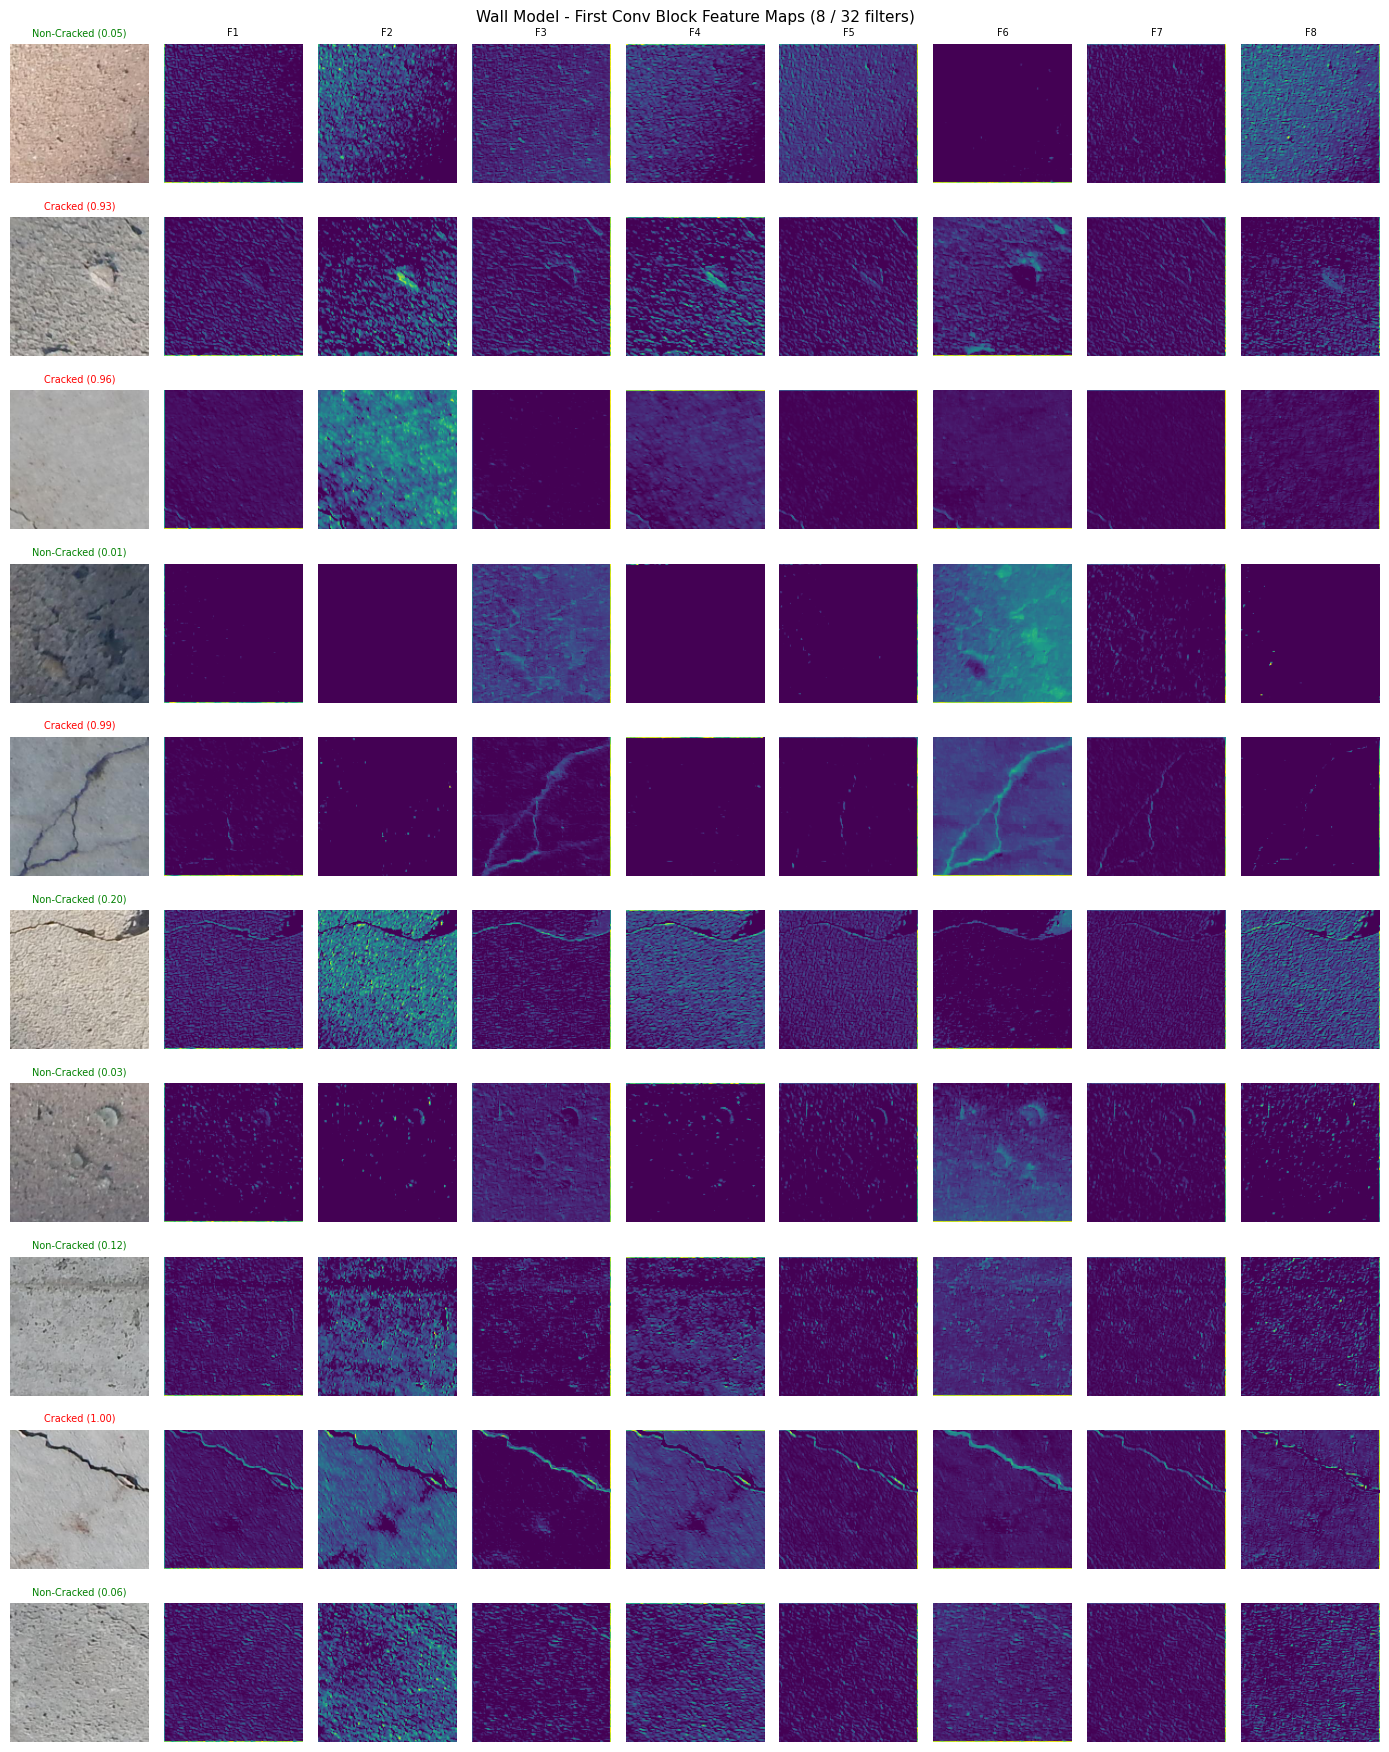

In [ ]:
# Pick 10 random images for feature map visualization
random.seed(42)
sample_paths = random.sample(image_paths, 10)

# First conv block: Conv2d → BatchNorm2d → ReLU → MaxPool2d
wall_first_block = nn.Sequential(*list(model_walls.features.children())[:4]).to(device)
wall_first_block.eval()
model_walls.eval()

# Apply the first 8 filters of the first conv block to the sample images and visualize
N_FILTERS = 8
fig, axes = plt.subplots(10, N_FILTERS + 1, figsize=(14, 18))

# Loop through each sample image and visualize the original image + feature maps
for row, img_path in enumerate(sample_paths):
    
    # Convert image to 256x256x3 array
    img_disp = np.asarray(Image.open(img_path).convert("RGB"))

    # Retrieve output probability
    x = preprocess_image(img_path).to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model_walls(x)).item()
        feat = wall_first_block(x).cpu() 

    # Label images based on 0.5 threshold
    label = "Cracked" if prob >= 0.5 else "Non-Cracked"
    colour = "red" if label == "Cracked" else "green"

    # Impose label and probability on original image as titles
    axes[row, 0].imshow(img_disp)
    axes[row, 0].set_title(f"{label} ({prob:.2f})", fontsize=7, color=colour)
    axes[row, 0].axis("off")

    # Number filters
    for ch in range(N_FILTERS):
        fm = feat[0, ch].numpy()
        axes[row, ch + 1].imshow(fm, cmap="viridis")
        axes[row, ch + 1].set_title(f"F{ch + 1}" if row == 0 else "", fontsize=7)
        axes[row, ch + 1].axis("off")

plt.suptitle("Wall Model - First Conv Block Feature Maps (8 / 32 filters)", fontsize=11)
plt.tight_layout(h_pad=0)
plt.show()

#### Deck Model – First Conv Layer Filters
Same 10 images passed through the first convolutional block of `model_decks_cleaned`.

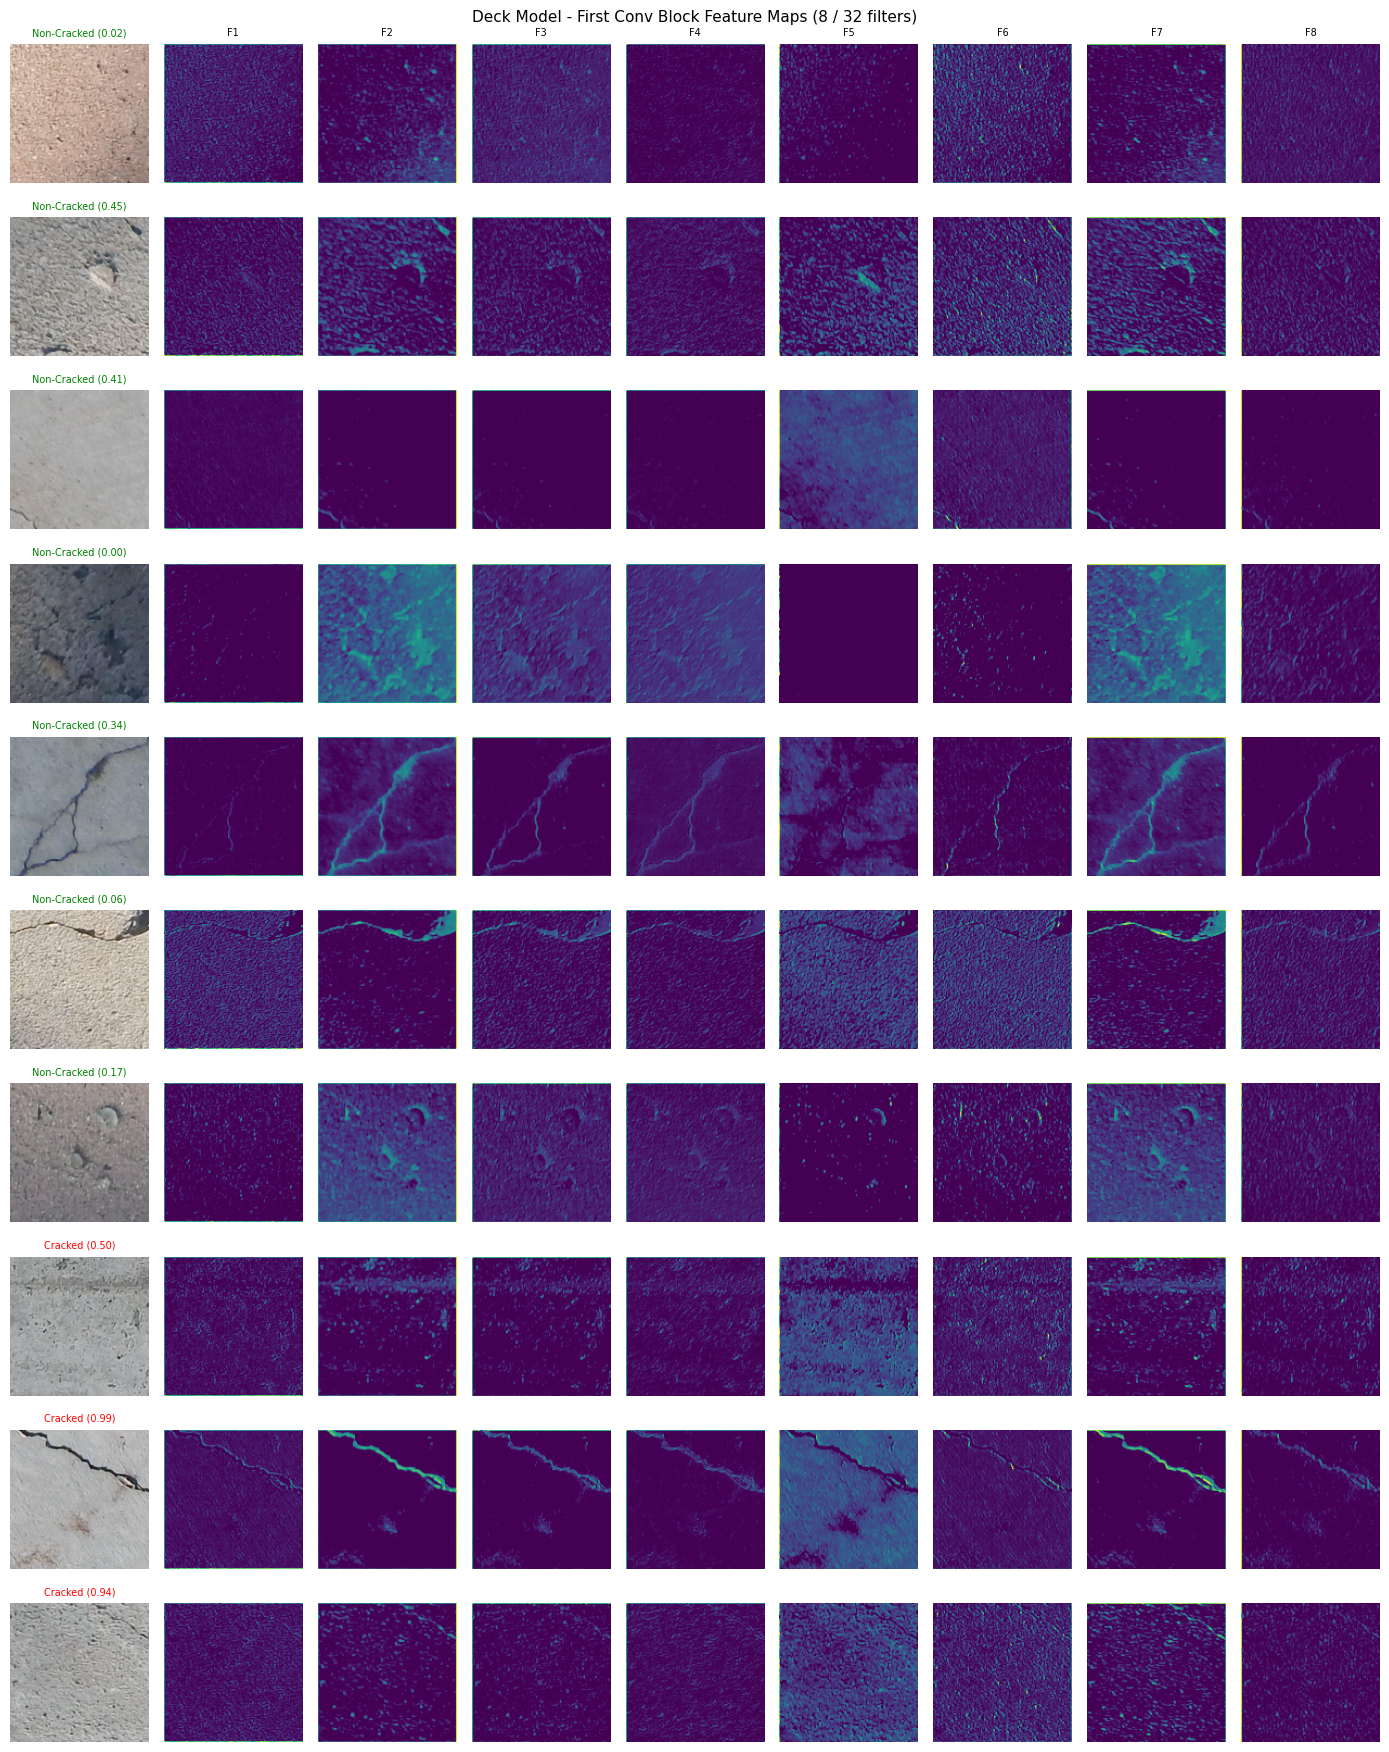

In [ ]:
# First conv block: Conv2d → BatchNorm2d → ReLU → MaxPool2d
deck_first_block = nn.Sequential(*list(model_decks.features.children())[:4]).to(device)
deck_first_block.eval()
model_decks.eval()

# same logic as above but for deck model
fig, axes = plt.subplots(10, N_FILTERS + 1, figsize=(14, 18))
for row, img_path in enumerate(sample_paths):
    img_disp = np.asarray(Image.open(img_path).convert("RGB"))
    x = preprocess_image(img_path).to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model_decks(x)).item()
        feat = deck_first_block(x).cpu()   # (1, 32, H, W)
    label = "Cracked" if prob >= 0.5 else "Non-Cracked"
    colour = "red" if label == "Cracked" else "green"
    axes[row, 0].imshow(img_disp)
    axes[row, 0].set_title(f"{label} ({prob:.2f})", fontsize=7, color=colour)
    axes[row, 0].axis("off")
    for ch in range(N_FILTERS):
        fm = feat[0, ch].numpy()
        axes[row, ch + 1].imshow(fm, cmap="viridis")
        axes[row, ch + 1].set_title(f"F{ch + 1}" if row == 0 else "", fontsize=7)
        axes[row, ch + 1].axis("off")

plt.suptitle("Deck Model - First Conv Block Feature Maps (8 / 32 filters)", fontsize=11)
plt.tight_layout(h_pad=0)
plt.show()